# Loan Applications & Funding Trends Analysis

## Imported the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [2]:
df = pd.read_excel("D:/Project files/financial_loan.xlsx")

In [4]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [6]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


## Data size

In [7]:
print("No of rows:",df.shape[0])

No of rows: 38576


In [8]:
print("No of columns:",df.shape[1])

No of columns: 24


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

### Data types

In [9]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

## set the datetype 

In [10]:
date_cols = ["issue_date", "last_credit_pull_date", "last_payment_date", "next_payment_date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], unit='D', origin='1899-12-30')

print(df['issue_date'].head(10))

0   2021-02-11
1   2021-01-01
2   2021-01-05
3   2021-02-25
4   2021-01-01
5   2021-07-17
6   2021-11-19
7   2021-06-11
8   2021-09-02
9   2021-02-09
Name: issue_date, dtype: datetime64[ns]


In [110]:
print(df['issue_date'].dtype)
print(df['issue_date'].head(10))

datetime64[ns]
0   2021-02-11
1   2021-01-01
2   2021-01-05
3   2021-02-25
4   2021-01-01
5   2021-07-17
6   2021-11-19
7   2021-06-11
8   2021-09-02
9   2021-02-09
Name: issue_date, dtype: datetime64[ns]


In [105]:
print(df[date_cols].dtypes)
print(df[date_cols].head())

issue_date               int64
last_credit_pull_date    int64
last_payment_date        int64
next_payment_date        int64
dtype: object
   issue_date  last_credit_pull_date  last_payment_date  next_payment_date
0       44238                  44452              44299              44329
1       44197                  44544              44211              44242
2       44201                  44542              44205              44236
3       44252                  44542              44267              44298
4       44197                  44544              44211              44242


In [108]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,44393.105273,44355.567062,44373.411214,44403.862738,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,103.463988,91.545702,104.128856,104.356380,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,44197.000000,44204.000000,44204.000000,44235.000000,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,44297.000000,44301.000000,44271.000000,44302.000000,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,44388.000000,44332.000000,44361.000000,44391.000000,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,44480.000000,44421.000000,44454.000000,44484.000000,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,44542.000000,44581.000000,44545.000000,44576.000000,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


### Total Loan Applications

In [13]:
count_loan_applications=df['id'].count()
print("Total_loan_applications",count_loan_applications)

Total_loan_applications 38576


### MTD-Total loan applications

In [10]:
latest_date=df["issue_date"].max()
latest_year=latest_date.year
latest_month=latest_date.month

mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_loan_applications=mtd_data["id"].count()

print(f"MTD Loan Applications(for {latest_date.strftime('%B %Y')}):{mtd_loan_applications}")

MTD Loan Applications(for December 2021):4314


### Total Funded Amount

In [49]:
total_funded_amount=df['loan_amount'].sum()
total_funded_in_millions=total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_in_millions))

Total Funded Amount: $435.76M


### MTD-Total Funded Amount

In [50]:
latest_date=df["issue_date"].max()
latest_year=latest_date.year
latest_month=latest_date.month

mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_total_funded_amount=mtd_data['loan_amount'].sum()
mtd_total_funded_in_millions=mtd_total_funded_amount/1000000

print("MTD Total funded amount: ${:.2f}m".format(mtd_total_funded_in_millions))

MTD Total funded amount: $435.76m


### Total Amount Received

In [53]:
total_amount_recived=df['total_payment'].sum()
total_amount_recived_millions=total_amount_recived/1000000
print("Total Amount Recieved: ${:.2f}M".format(total_amount_recived_millions))

Total Amount Recieved: $473.07M


### MTD-Total Amount Received

In [54]:
latest_date=df["issue_date"].max()
latest_year=latest_date.year
latest_month=latest_date.month

mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_total_amount_recived=mtd_data['total_payment'].sum()
mtd_total_amount_recived_in_millions=mtd_total_amount_recived/1000000

print("MTD Total amount received: ${:.2f}m".format(mtd_total_amount_recived_in_millions))

MTD Total amount received: $473.07m


### Average interest rate

In [55]:
average_interest_rate=df['int_rate'].mean()*100
print('Average Interest Rate: {:.2f}%'.format(average_interest_rate))

Average Interest Rate: 12.05%


### Average Debt-to-income Ratio (DTI)

In [56]:
average_DTI=df['dti'].mean()*100
print('Average Debt-to-income Ratio: {:.2f}%'.format(average_DTI))

Average Debt-to-income Ratio: 13.33%


### Good Loan metrics

In [57]:
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]
total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()         
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000
good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded amount (millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (millions): ${:.3f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded amount (millions): $370.22M
Good Loan Total Received (millions): $435.786M
Percentage of Good Loan Applications: 86.18%


### Bad Loan metrics

In [58]:
bad_loans = df[df['loan_status'].isin(["Charged Off"])]
total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()         
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_millions = bad_loan_received / 1000000
bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("bad Loan Applications:", bad_loan_applications)
print("bad Loan Funded amount (millions): ${:.2f}M".format(bad_loan_funded_amount_millions))
print("bad Loan Total Received (millions): ${:.2f}M".format(bad_loan_received_millions))
print("Percentage of bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

bad Loan Applications: 5333
bad Loan Funded amount (millions): $65.53M
bad Loan Total Received (millions): $37.28M
Percentage of bad Loan Applications: 13.82%


### Monthly Trends by Issue Date For Total Funded Amount

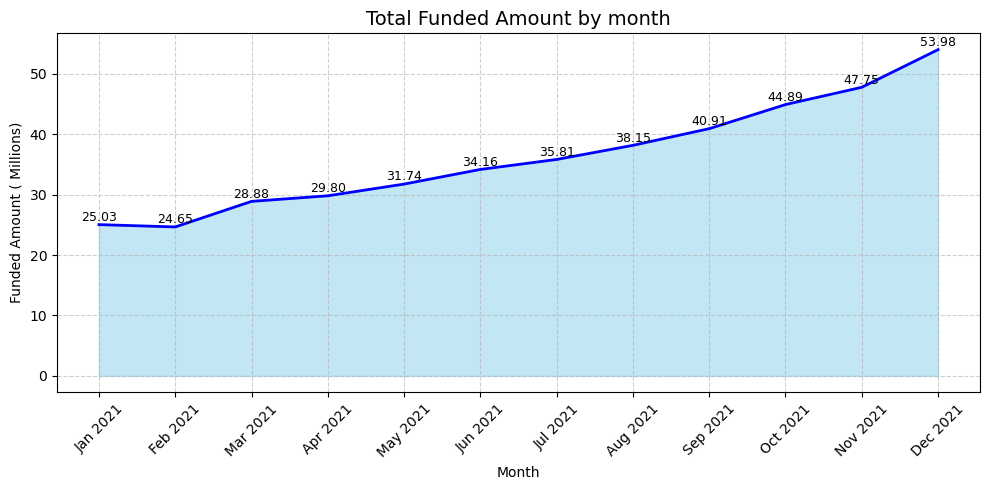

In [15]:
monthly_funded=(
        df.sort_values('issue_date')
        .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %Y'))
        .groupby('month_name',sort=False)['loan_amount']
        .sum()
        .div(1000000)
        .reset_index(name='loan_amount_millions')
)
plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'], monthly_funded['loan_amount_millions'],color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='blue',linewidth=2)
    


for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}",
        ha='center',va='bottom',fontsize=9,rotation=0,color='black')
        
plt.title('Total Funded Amount by month',fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ( Millions)')
plt.xticks(ticks=range(len(monthly_funded)),labels=monthly_funded['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date For Total Amount Received

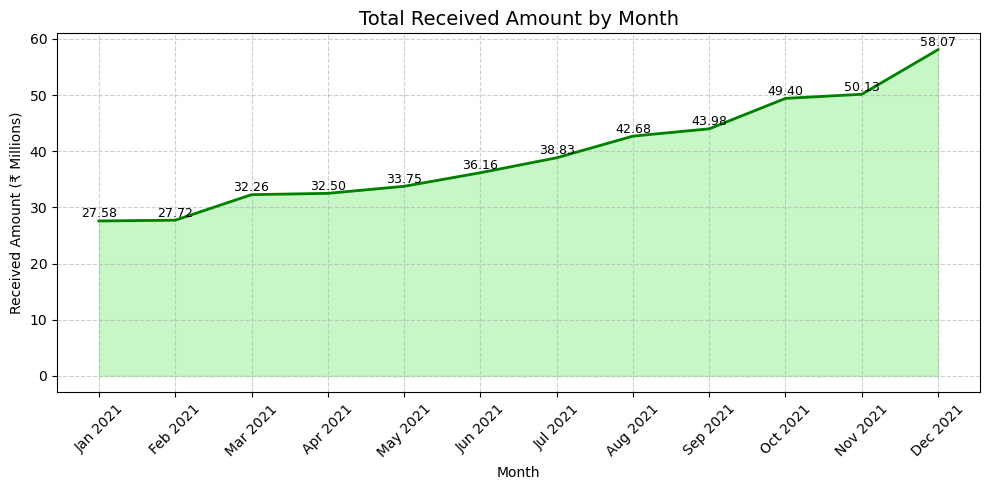

In [16]:
monthly_received = (
df.sort_values('issue_date')
        .assign (month_name=lambda x: x['issue_date' ] .dt. strftime ( '%b %Y' ) )
        .groupby('month_name', sort=False) ['total_payment' ]
        . sum()
        .div(1000000)
        .reset_index(name='received_amount_millions')
)
plt.figure(figsize=(10, 5))
plt.fill_between(monthly_received['month_name' ], monthly_received['received_amount_millions'],
        color='lightgreen', alpha=0.5)
plt.plot (monthly_received['month_name'], monthly_received['received_amount_millions' ],
        color='green', linewidth=2)
for i, row in monthly_received.iterrows():
        plt.text(i, row['received_amount_millions'] + 0.1, f"{row['received_amount_millions']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel ('Month')
plt.ylabel ('Received Amount (₹ Millions)')
plt.xticks (ticks=range(len (monthly_received)) , labels=monthly_received['month_name' ], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout ()
plt.show()

### Monthly Trends by Issue Date For Total Loan Applications

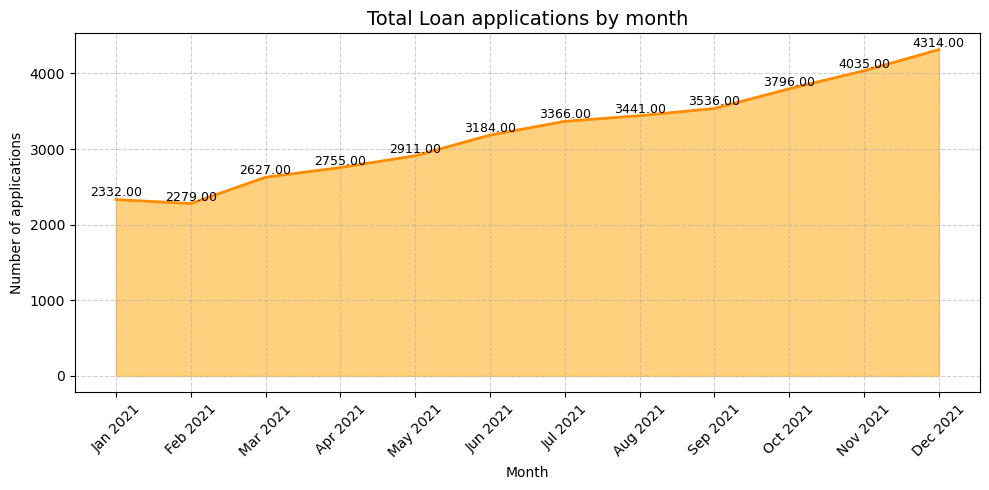

In [17]:
monthly_applications=(
        df.sort_values('issue_date')
        .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %Y'))
        .groupby('month_name',sort=False)['id']
        .count()
        .reset_index(name='loan_applications_count')
)
plt.figure(figsize=(10,5))
plt.fill_between(monthly_applications['month_name'], monthly_applications['loan_applications_count'],
                 color='orange',alpha=0.5)
plt.plot(monthly_applications['month_name'],monthly_applications['loan_applications_count'],
         color='darkorange',linewidth=2)
    


for i, row in monthly_applications.iterrows():
    plt.text(i, row['loan_applications_count'] + 0.5, f"{row['loan_applications_count']:.2f}",
        ha='center',va='bottom',fontsize=9,rotation=0,color='black')
        
plt.title('Total Loan applications by month',fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of applications')
plt.xticks(ticks=range(len(monthly_applications)),labels=monthly_applications['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis By State For Total Funded Amount

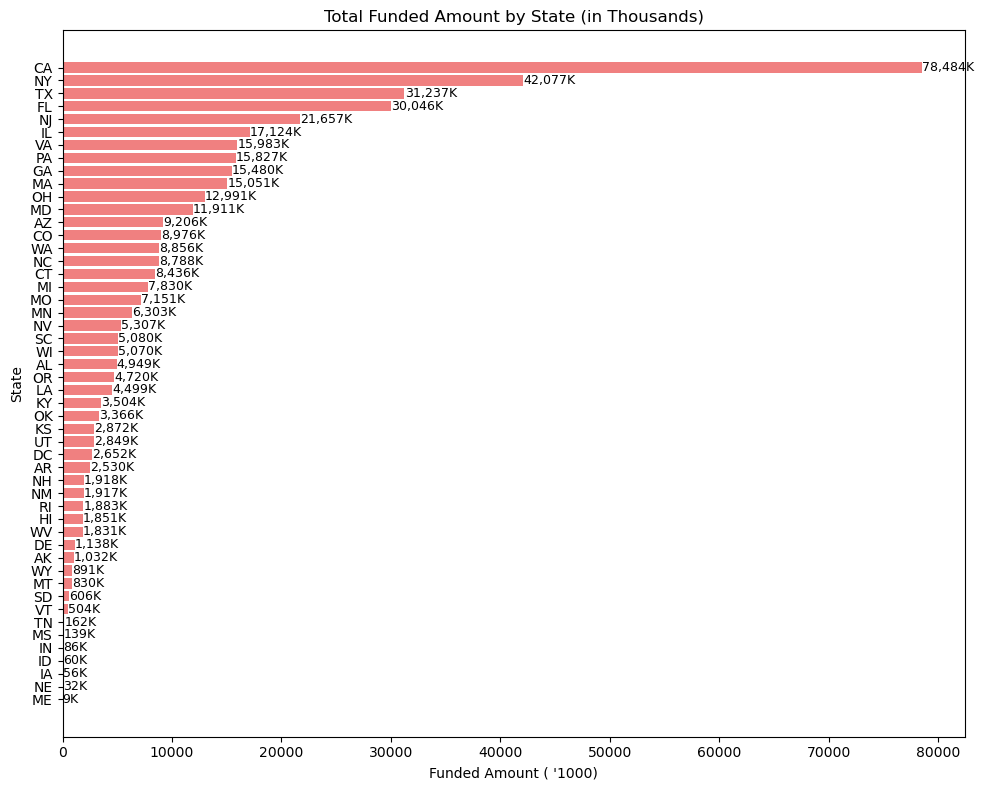

In [26]:
state_funding=df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands=state_funding / 1000

plt.figure(figsize=(10,8))
bars=plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
                f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in Thousands)')
plt.xlabel('Funded Amount ( \'1000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis By State For Total Received Amount

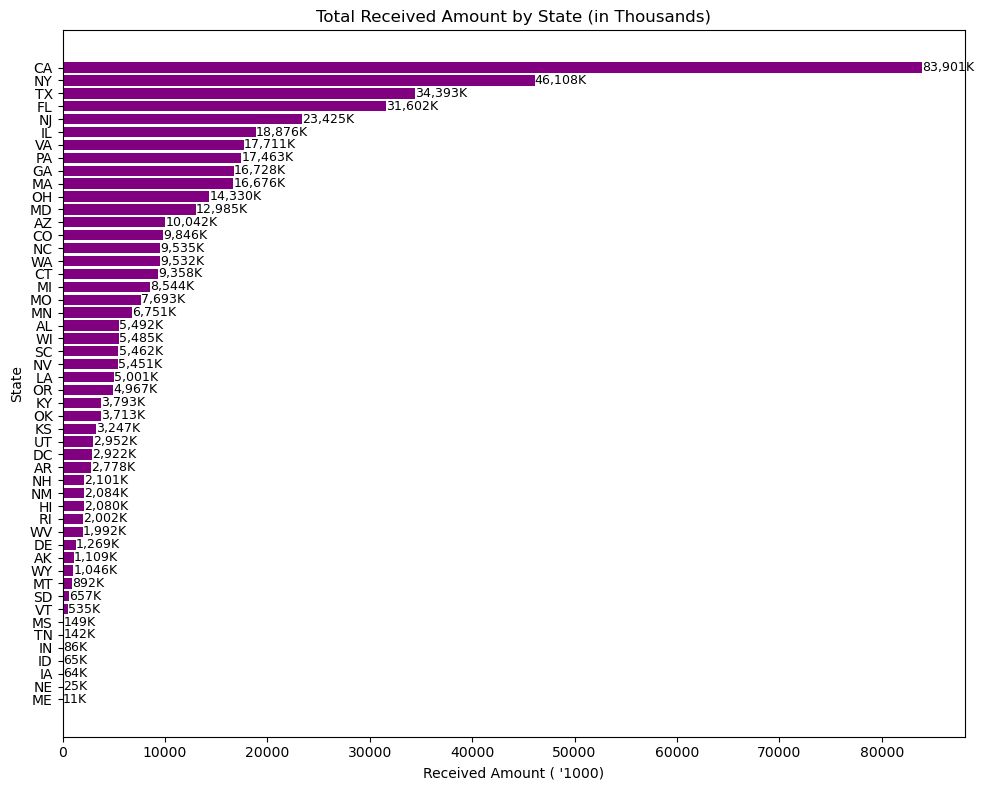

In [31]:
state_received_amount=df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_received_amount_thousands=state_received_amount / 1000

plt.figure(figsize=(10,8))
bars=plt.barh(state_received_amount_thousands.index, state_received_amount_thousands.values, color='Purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
                f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Received Amount by State (in Thousands)')
plt.xlabel('Received Amount ( \'1000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis By State For Total Loan Applications

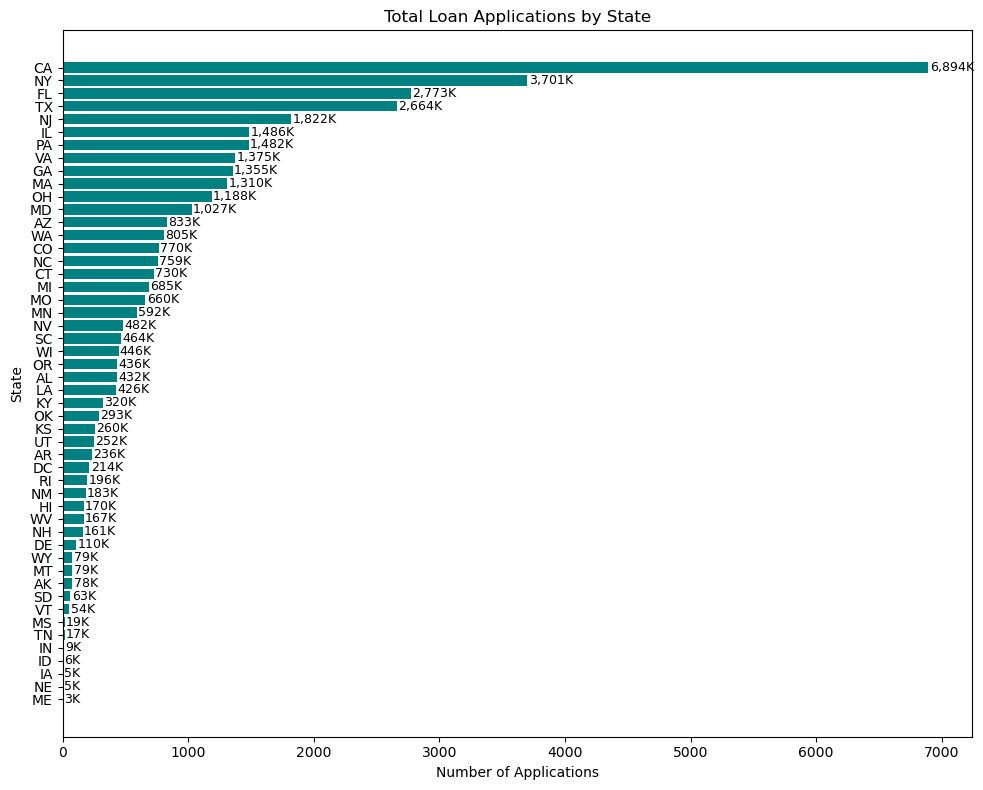

In [35]:
state_application_count=df.groupby('address_state')['id'].count().sort_values(ascending=True)

plt.figure(figsize=(10,8))
bars=plt.barh(state_application_count.index, state_application_count.values, color='teal')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
                f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Loan Applications by State')
plt.xlabel('Number of Applications')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

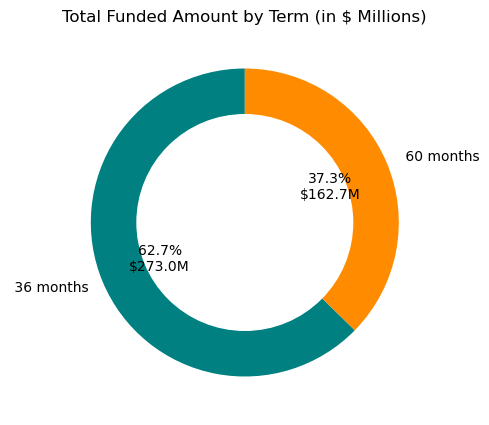

In [39]:
term_funding_millions=df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
        term_funding_millions,
        labels=term_funding_millions.index,
        autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
        startangle=90,
        wedgeprops={'width':0.4},
        colors=['teal', 'darkorange'] 
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()

### Loan Term Analysis by Total Recieved Amount

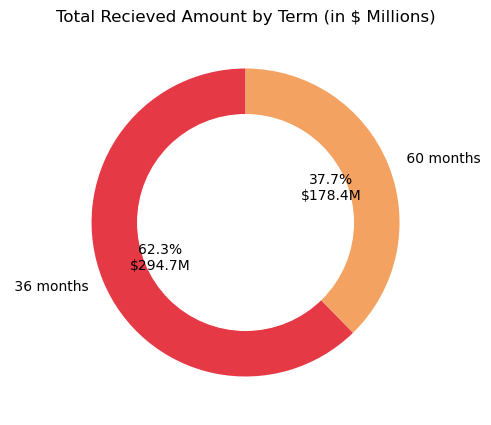

In [45]:
term_recived_millions=df.groupby('term')['total_payment'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
        term_recived_millions,
        labels=term_recived_millions.index,
        autopct=lambda p: f"{p:.1f}%\n${p*sum(term_recived_millions)/100:.1f}M",
        startangle=90,
        wedgeprops={'width':0.4},
        colors=['#E63946', '#F4A261', '#E9C46A'] 
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
plt.title("Total Recieved Amount by Term (in $ Millions)")
plt.show()

### Loan Term Analysis by Total Loan Applications

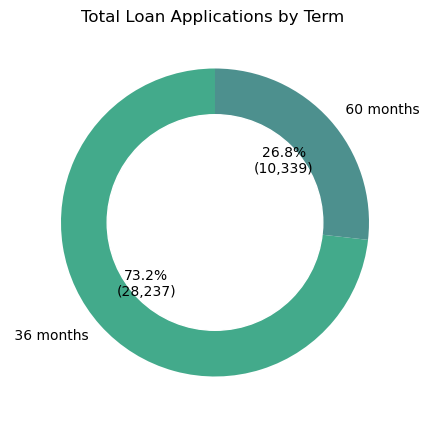

In [51]:
term_loan_applications=df.groupby('term')['id'].count()

plt.figure(figsize=(5,5))
plt.pie(
        term_loan_applications,
        labels=term_loan_applications.index,
        autopct=lambda p: f"{p:.1f}%\n({p*sum(term_loan_applications)/100:,.0f})",
        startangle=90,
        wedgeprops={'width':0.4},
        colors=['#43AA8B', '#4D908E', '#577590'] 
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
plt.title("Total Loan Applications by Term ")
plt.show()

### Total Loan Applications by Employee Length

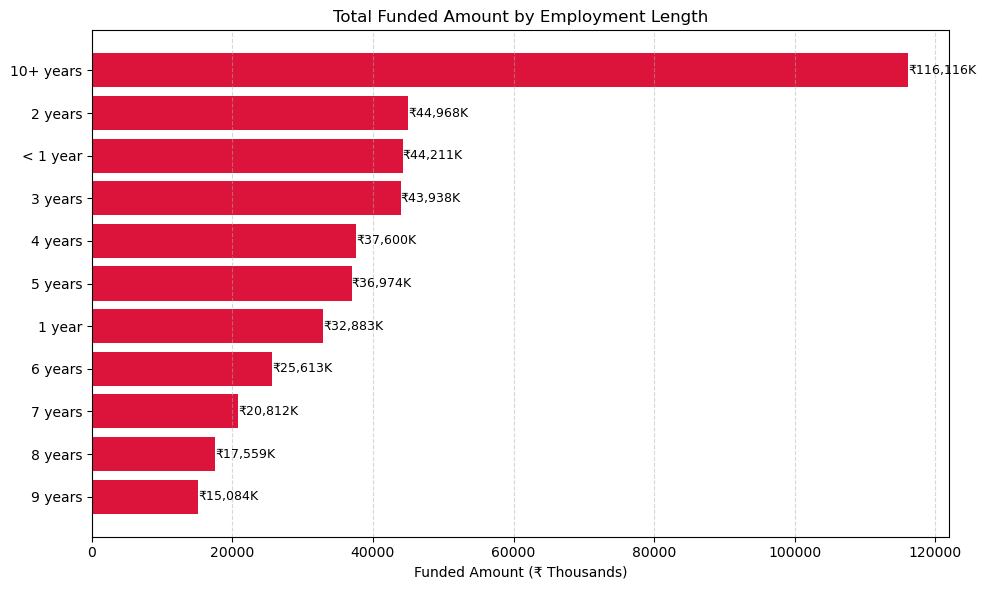

In [65]:
emp_funding_thousands= df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_funding_thousands.index,emp_funding_thousands,color='crimson')

for bar in bars:
    width=bar.get_width()
    plt.text(width + 5,bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.0f}K",va='center',fontsize=9)

plt.xlabel("Funded Amount (₹ Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

### Total Amount Recieved by Employee Length

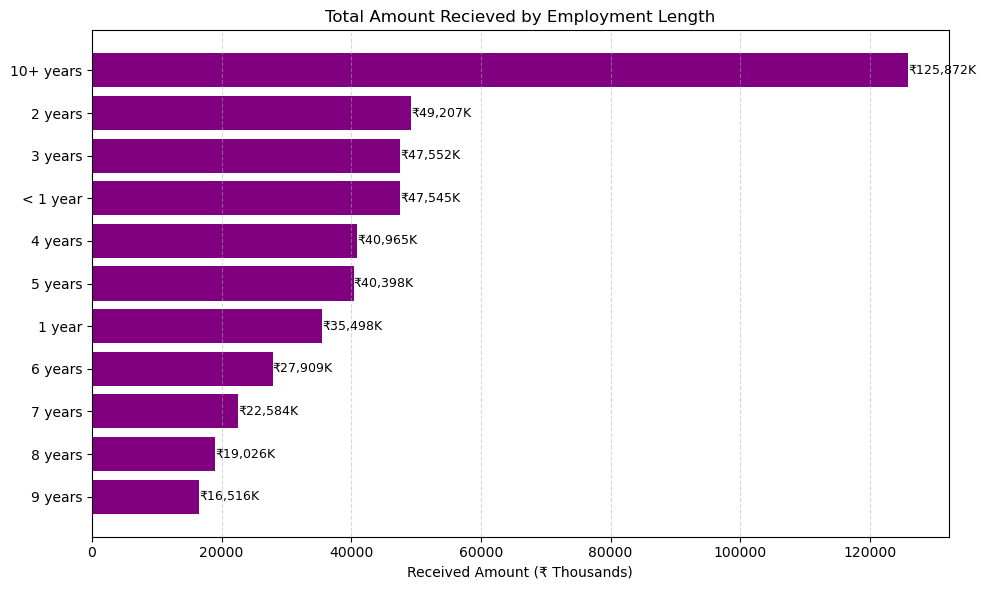

In [60]:
emp_recived_millions= df.groupby('emp_length')['total_payment'].sum().sort_values()/1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_recived_millions.index,emp_recived_millions,color='purple')

for bar in bars:
    width=bar.get_width()
    plt.text(width + 5,bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.0f}K",va='center',fontsize=9)

plt.xlabel("Received Amount (₹ Thousands)")
plt.title("Total Amount Recieved by Employment Length")
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount

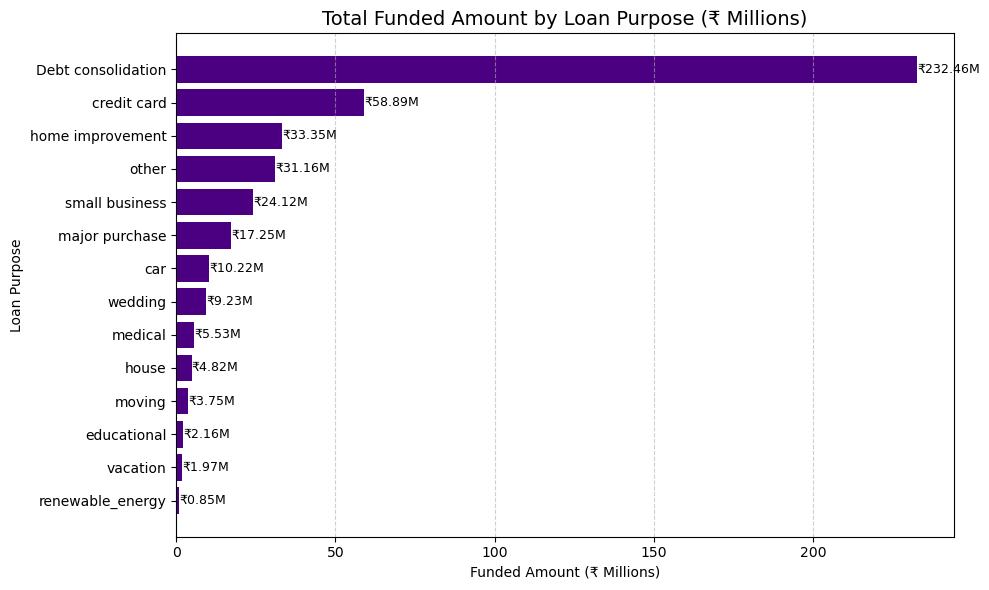

In [67]:
purpose_funding_millions= (df.groupby('purpose')['loan_amount'].sum().sort_values()/1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_funding_millions.index,purpose_funding_millions,color='indigo')

for bar in bars:
    width=bar.get_width()
    plt.text(width + 0.1,bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.2f}M",va='center',fontsize=9)

plt.title("Total Funded Amount by Loan Purpose (₹ Millions)", fontsize=14)
plt.xlabel("Funded Amount (₹ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

### Total Amount Received by Loan Purpose

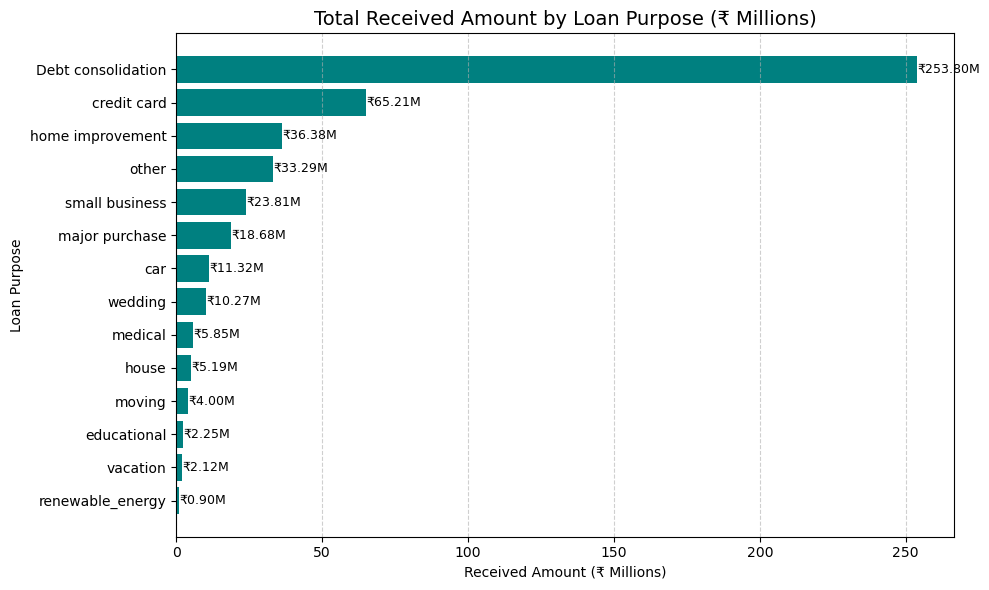

In [69]:
purpose_received_millions= (df.groupby('purpose')['total_payment'].sum().sort_values()/1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_received_millions.index,purpose_received_millions,color='teal')

for bar in bars:
    width=bar.get_width()
    plt.text(width + 0.1,bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.2f}M",va='center',fontsize=9)

plt.title("Total Received Amount by Loan Purpose (₹ Millions)", fontsize=14)
plt.xlabel("Received Amount (₹ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

### Total Loan Applications by Loan Purpose

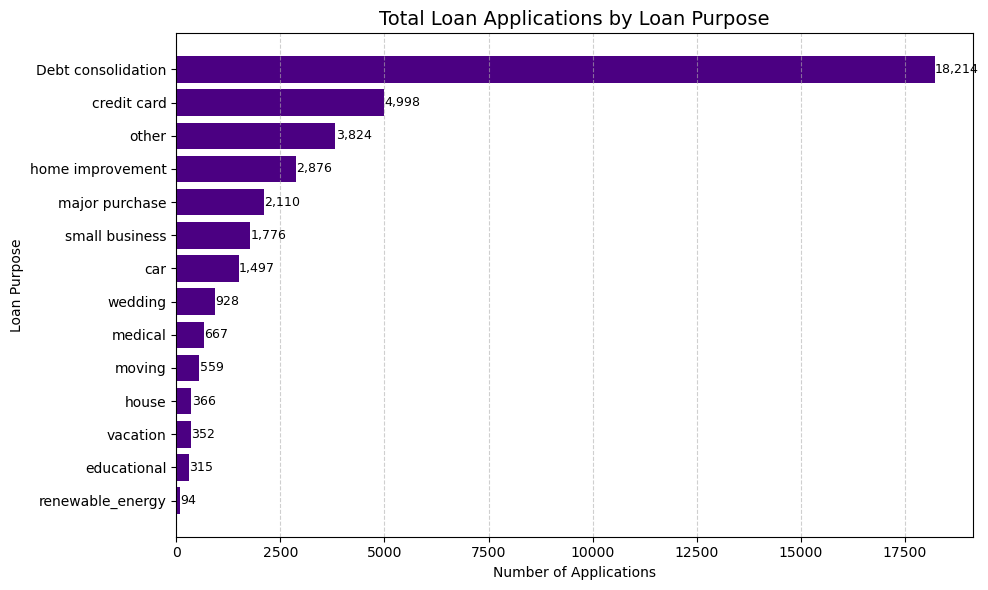

In [78]:
purpose_loan_applications=df.groupby('purpose')['id'].count().sort_values()

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_loan_applications.index,purpose_loan_applications,color='indigo')

for bar in bars:
    width=bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}", va='center', fontsize=9)

plt.title("Total Loan Applications by Loan Purpose", fontsize=14)
plt.xlabel("Number of Applications")
plt.ylabel("Loan Purpose")
plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

### Home ownership by Total Funded Amount

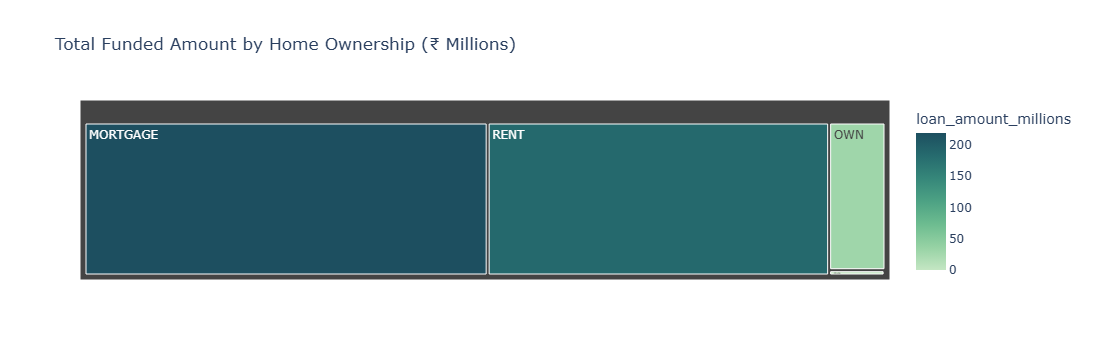

In [88]:
home_funding=df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions']=home_funding['loan_amount'] / 1000000

fig =px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blugrn',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)
fig.show()

### Home ownership by Total Received Amount

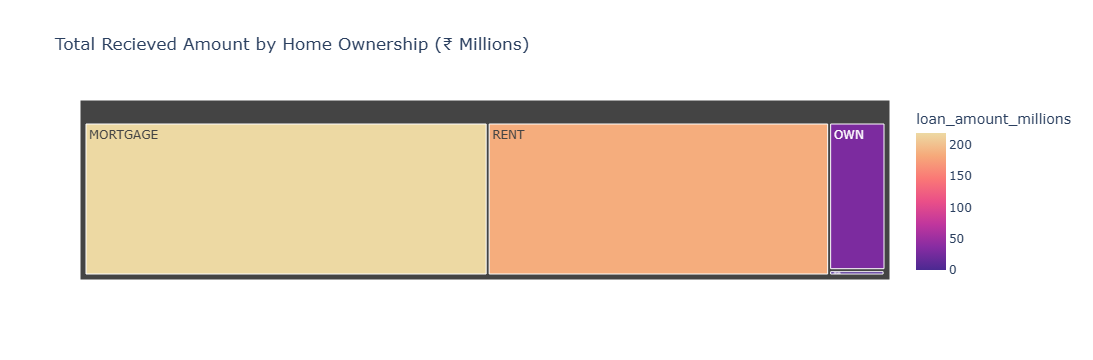

In [89]:
home_received=df.groupby('home_ownership')['total_payment'].sum().reset_index()
home_received['loan_amount_millions']=home_received['total_payment'] / 1000000

fig =px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Agsunset',
    title='Total Recieved Amount by Home Ownership (₹ Millions)'
)
fig.show()

### Home ownership by Total Loan Applications

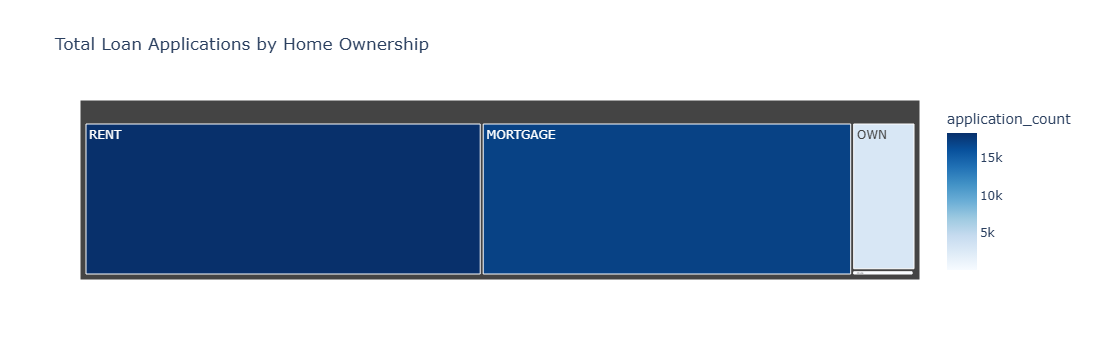

In [95]:
home_applications=df.groupby('home_ownership')['total_payment'].count().reset_index()
home_applications = home_applications.rename(columns={'total_payment': 'application_count'})

fig =px.treemap(
    home_applications,
    path=['home_ownership'],
    values='application_count',
    color='application_count',
    color_continuous_scale='Blues',
    title='Total Loan Applications by Home Ownership'
)
fig.show()

In [100]:
df.to_excel('D:/Project files/financial_loan.xlsx',index=False)


In [101]:
import pandas as pd
df = pd.read_excel('D:/Project files/financial_loan.xlsx')
df.head()

True


In [11]:
import pandas as pd
df = pd.read_excel('D:/Project files/financial_loan.xlsx')
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [12]:
df.to_excel('D:/Project files/financial_loan.xlsx',index=False)